In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("Dataset.csv")

# Select only needed columns
data = df[["Age", "YearsAtCompany", "MonthlyIncome", "Attrition", "Gender"]].copy()

# Clean and format data
data["Attrition"] = data["Attrition"].astype(str).str.strip().str.title()
data["Gender"] = data["Gender"].astype(str).str.strip().str.title()
data["Age"] = pd.to_numeric(data["Age"], errors="coerce")
data["YearsAtCompany"] = pd.to_numeric(data["YearsAtCompany"], errors="coerce")
data["MonthlyIncome"] = pd.to_numeric(data["MonthlyIncome"], errors="coerce")
data.dropna(subset=["Age", "YearsAtCompany", "MonthlyIncome", "Attrition"], inplace=True)

print("Data cleaned and ready.")


Data cleaned and ready.


In [7]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [9]:
# Calculate attrition percentage
total_employees = len(df)
employees_left = len(df[df['Attrition'] == 'Yes'])

attrition_percentage = (employees_left / total_employees) * 100

print("Total Employees :", total_employees)
print("Employees Left  :", employees_left)
print("Attrition %     :", round(attrition_percentage, 2), "%")


Total Employees : 1470
Employees Left  : 237
Attrition %     : 16.12 %


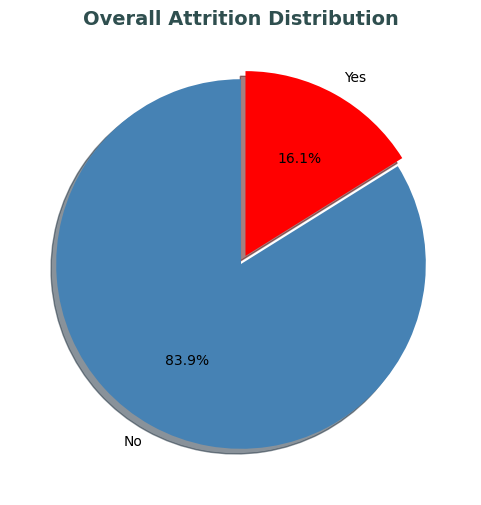

Attrition Counts:
 Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [7]:
# Clean and count attrition
df["Attrition"] = df["Attrition"].astype(str).str.strip().str.title()
attr_count = df["Attrition"].value_counts()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(
    attr_count.values,
    labels=attr_count.index,
    autopct='%1.1f%%',        # shows percentage
    colors=["#4682B4", "red"],  # blue for stayed, red for left
    startangle=90,
    explode=(0, 0.05),        # small pop-out effect for clarity
    shadow=True
)

plt.title("Overall Attrition Distribution", fontsize=14, fontweight='bold', color='#2F4F4F')
plt.show()

print("Attrition Counts:\n", attr_count)


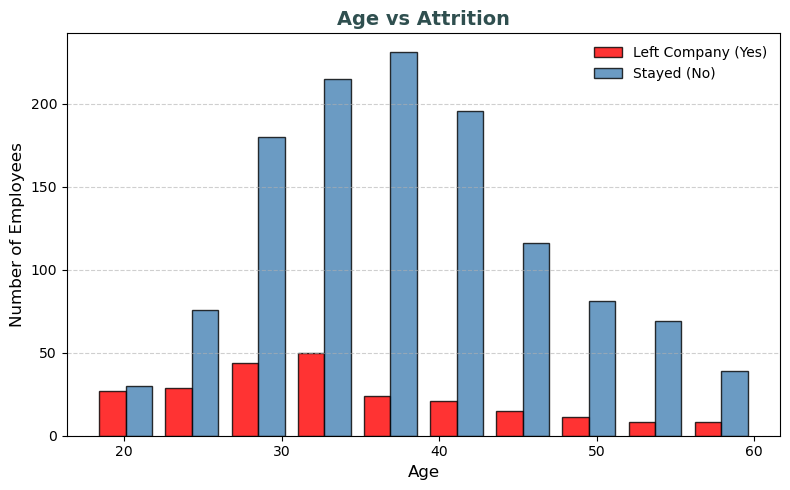

In [9]:
data = df[["Age", "Attrition"]].copy()
data["Attrition"] = data["Attrition"].astype(str).str.strip().str.title()
data["Age"] = pd.to_numeric(data["Age"], errors="coerce")
data.dropna(subset=["Age", "Attrition"], inplace=True)

# Separate groups
left = data[data["Attrition"] == "Yes"]["Age"]
stay = data[data["Attrition"] == "No"]["Age"]

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(
    [left, stay],
    bins=10,
    color=["red", "#4682B4"],   # normal red & steel blue
    label=["Left Company (Yes)", "Stayed (No)"],
    edgecolor="black",
    alpha=0.8
)

plt.title("Age vs Attrition", fontsize=14, fontweight="bold", color="#2F4F4F")
plt.xlabel("Age", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

C:\Users\aishu\AppData\Local\Temp\ipykernel_21772\3789688219.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate_tenure = df.groupby("TenureBand")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)


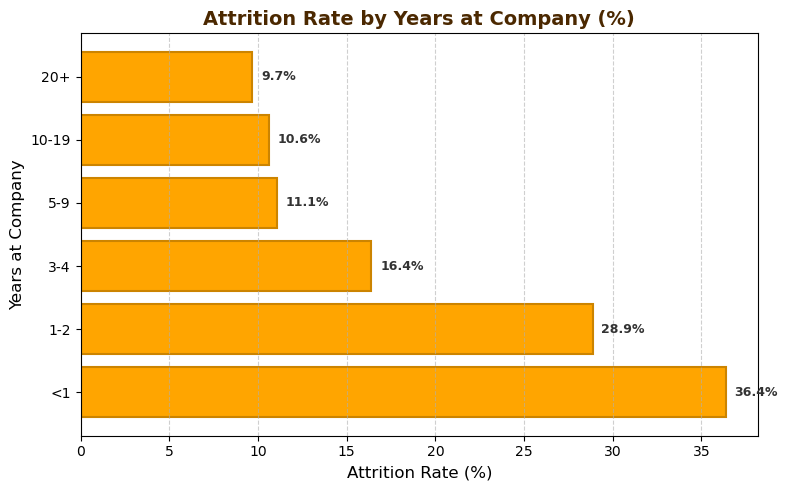

In [29]:
df["Attrition"] = df["Attrition"].astype(str).str.strip().str.title()
df["YearsAtCompany"] = pd.to_numeric(df["YearsAtCompany"], errors="coerce")
df.dropna(subset=["YearsAtCompany", "Attrition"], inplace=True)

# Create tenure bands
bins = [0, 1, 3, 5, 10, 20, 50]
labels = ["<1", "1-2", "3-4", "5-9", "10-19", "20+"]
df["TenureBand"] = pd.cut(df["YearsAtCompany"], bins=bins, labels=labels, right=False)

# Calculate attrition rate by tenure band
rate_tenure = df.groupby("TenureBand")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)

# --- Horizontal Bar Chart ---
plt.figure(figsize=(8,5))
bars = plt.barh(
    rate_tenure.index, rate_tenure.values,
    color="#FFA500",      # 🍊 Orange
    edgecolor="#CC8400",  # Darker orange border
    linewidth=1.5
)

# Chart style
plt.title("Attrition Rate by Years at Company (%)", fontsize=14, fontweight="bold", color="#4B2800")
plt.xlabel("Attrition Rate (%)", fontsize=12)
plt.ylabel("Years at Company", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.6)

# Add value labels to bars
for i, v in enumerate(rate_tenure.values):
    plt.text(v + 0.5, i, f"{v:.1f}%", va='center', fontsize=9, fontweight='bold', color="#333333")

plt.tight_layout()
plt.show()

C:\Users\aishu\AppData\Local\Temp\ipykernel_21772\675538342.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate_income = df.groupby("IncomeBand")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)


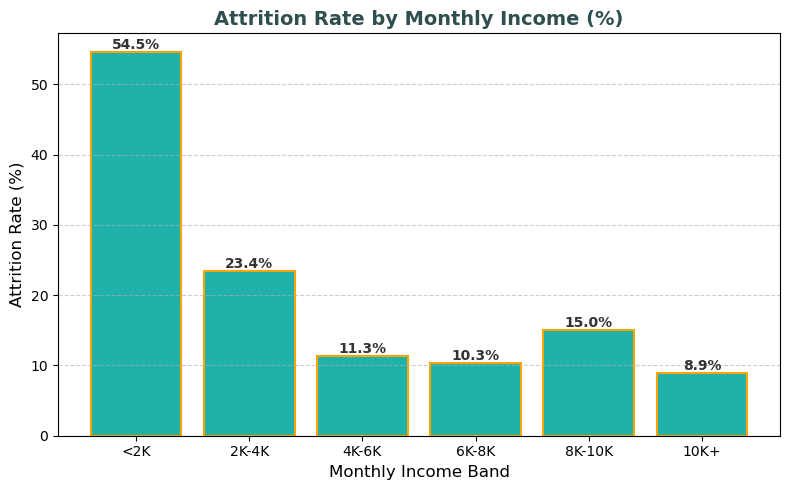

In [27]:
# Clean and prepare data
df["Attrition"] = df["Attrition"].astype(str).str.strip().str.title()
df["MonthlyIncome"] = pd.to_numeric(df["MonthlyIncome"], errors="coerce")
df.dropna(subset=["MonthlyIncome", "Attrition"], inplace=True)

# Create income bands
income_bins = [0, 2000, 4000, 6000, 8000, 10000, 20000]
income_labels = ["<2K", "2K-4K", "4K-6K", "6K-8K", "8K-10K", "10K+"]
df["IncomeBand"] = pd.cut(df["MonthlyIncome"], bins=income_bins, labels=income_labels, right=False)

# Calculate attrition rate
rate_income = df.groupby("IncomeBand")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)

# Plot Column Chart (Teal–Orange)
plt.figure(figsize=(8,5))
plt.bar(rate_income.index, rate_income.values,
        color="#20B2AA", edgecolor="#FFA500", linewidth=1.5)  # Teal fill, Orange border

plt.title("Attrition Rate by Monthly Income (%)", fontsize=14, fontweight="bold", color="#2F4F4F")
plt.xlabel("Monthly Income Band", fontsize=12)
plt.ylabel("Attrition Rate (%)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)

for i, v in enumerate(rate_income.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=10, fontweight="bold", color="#333333")

plt.tight_layout()
plt.show()


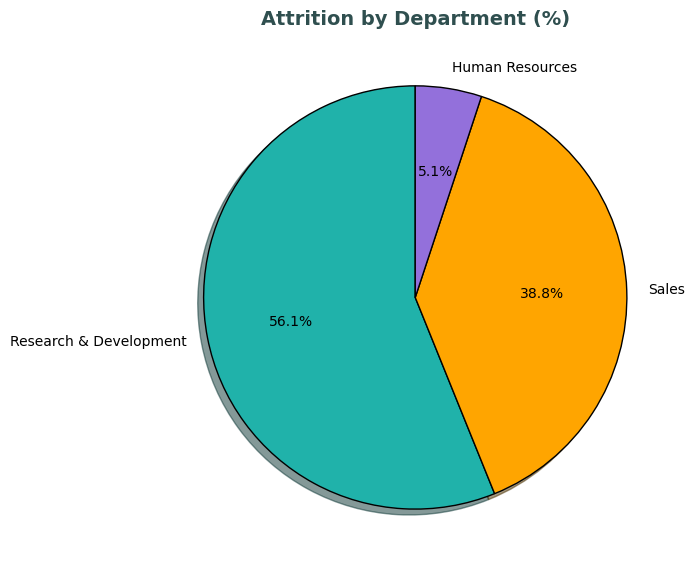

Attrition Count by Department:
 Department
Research & Development    133
Sales                      92
Human Resources            12
Name: count, dtype: int64


In [31]:
# Filter only employees who left
left_dept = df[df["Attrition"] == "Yes"]["Department"].value_counts()

# Plot Pie Chart
plt.figure(figsize=(7,7))
plt.pie(
    left_dept.values,
    labels=left_dept.index,
    autopct='%1.1f%%',
    colors=["#20B2AA", "#FFA500", "#9370DB", "#FF7F50", "#4682B4"],  # Teal, Orange, Purple, Coral, Blue
    startangle=90,
    shadow=True,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)

plt.title("Attrition by Department (%)", fontsize=14, fontweight='bold', color='#2F4F4F')
plt.tight_layout()
plt.show()

print("Attrition Count by Department:\n", left_dept)

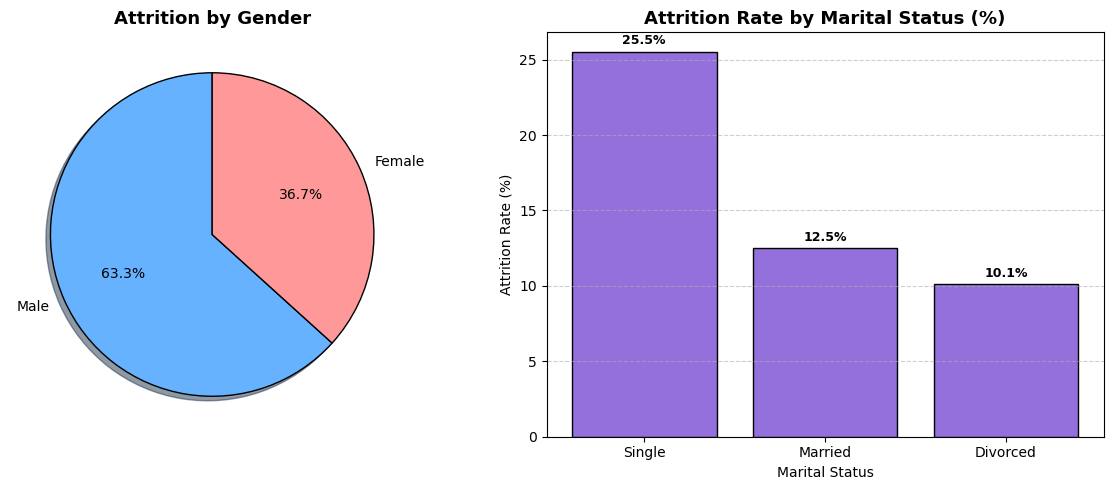

In [33]:

# Clean important columns
df["Attrition"] = df["Attrition"].astype(str).str.strip().str.title()
df["Gender"] = df["Gender"].astype(str).str.strip().str.title()
df["MaritalStatus"] = df["MaritalStatus"].astype(str).str.strip().str.title()

# ---------- 1️⃣ Attrition by Gender (Pie Chart Data) ----------
gender_attr = df[df["Attrition"] == "Yes"]["Gender"].value_counts()

# ---------- 2️⃣ Attrition by Marital Status (Bar Chart Data) ----------
marital_attr = df.groupby("MaritalStatus")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)
marital_attr = marital_attr.sort_values(ascending=False)

# ---------- Create Subplots ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: Pie Chart (Attrition by Gender) ---
axes[0].pie(
    gender_attr.values,
    labels=gender_attr.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=["#66B2FF", "#FF9999"],   # Blue & Pink
    shadow=True,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)
axes[0].set_title("Attrition by Gender", fontsize=13, fontweight="bold")

# --- Right: Bar Chart (Attrition by Marital Status) ---
x = np.arange(len(marital_attr.index))
axes[1].bar(
    x, marital_attr.values,
    color="#9370DB",   # Purple bars
    edgecolor="black"
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(marital_attr.index)
axes[1].set_title("Attrition Rate by Marital Status (%)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Marital Status")
axes[1].set_ylabel("Attrition Rate (%)")
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

# Add percentage labels above bars
for i, v in enumerate(marital_attr.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


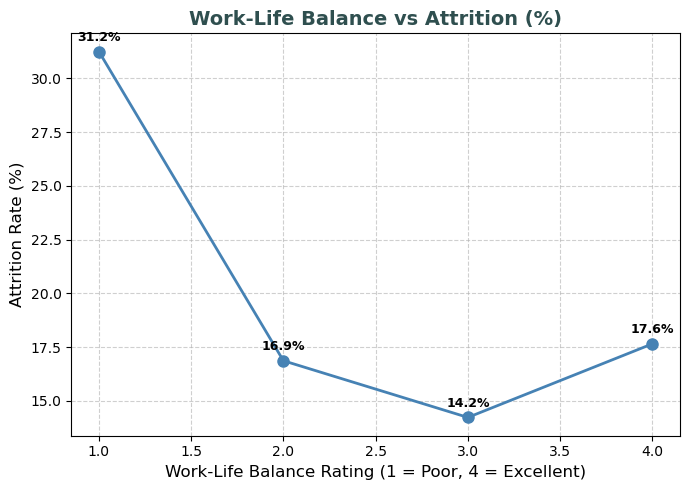

Attrition Rate by Work-Life Balance:

WorkLifeBalance
1    31.25
2    16.86
3    14.22
4    17.65
Name: Attrition, dtype: float64


In [35]:
df = df.dropna(subset=["WorkLifeBalance", "Attrition"])

# Calculate attrition rate for each Work-Life Balance rating
wlb_attr = df.groupby("WorkLifeBalance")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)

# --- Plot Line Chart ---
plt.figure(figsize=(7,5))
plt.plot(
    wlb_attr.index, wlb_attr.values,
    marker='o', color="#4682B4", linewidth=2, markersize=8  # Steel Blue line with circles
)

# Chart labels and title
plt.title("Work-Life Balance vs Attrition (%)", fontsize=14, fontweight='bold', color='#2F4F4F')
plt.xlabel("Work-Life Balance Rating (1 = Poor, 4 = Excellent)", fontsize=12)
plt.ylabel("Attrition Rate (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Value labels on each data point
for i, v in enumerate(wlb_attr.values):
    plt.text(wlb_attr.index[i], v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print("Attrition Rate by Work-Life Balance:\n")
print(wlb_attr.round(2))